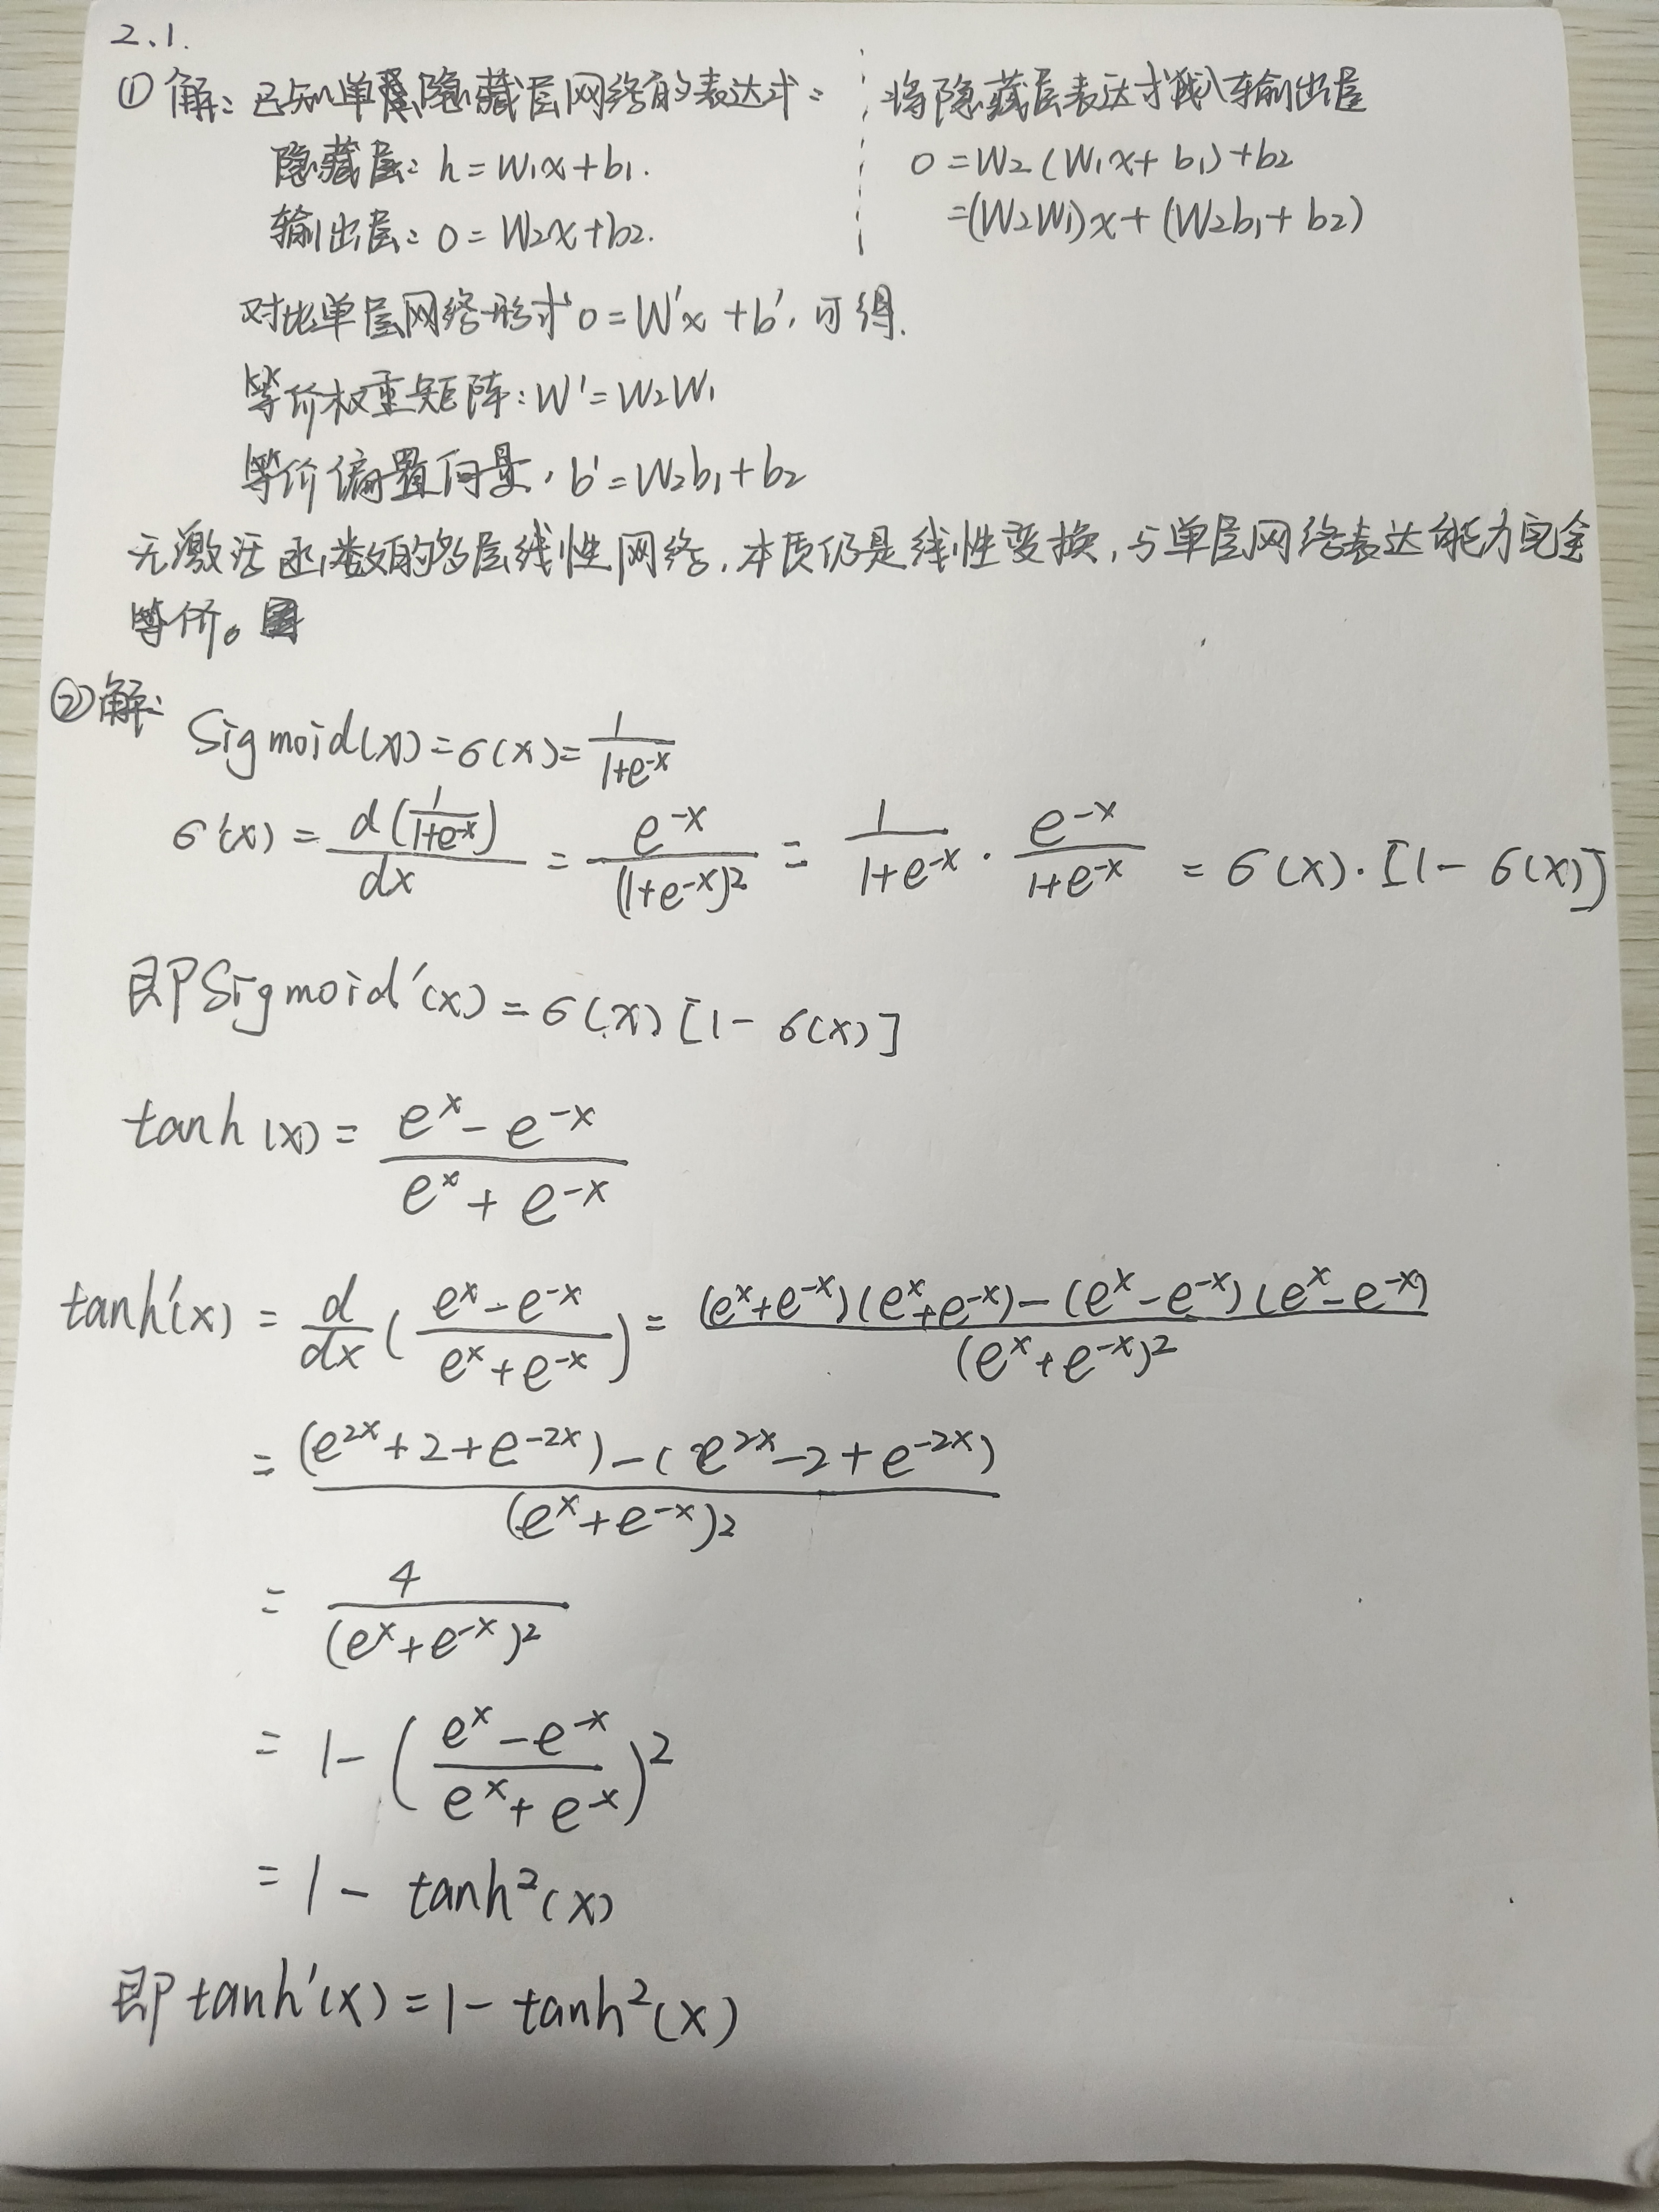

In [1]:
import torch
import torchvision
import torchvision.transforms as T

# 数据
transform = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.flatten())])
train = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(train, 64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, 64, shuffle=False)

# 参数初始化
in_dim = 784
hid_dim = 256
out_dim = 10
W1 = torch.randn(in_dim, hid_dim) * 0.01
b1 = torch.zeros(hid_dim)
W2 = torch.randn(hid_dim, out_dim) * 0.01
b2 = torch.zeros(out_dim)
for p in [W1, b1, W2, b2]: p.requires_grad_()

# 手动函数
def relu(x): return torch.maximum(x, torch.tensor(0.))
def softmax(x):
    x = x - x.max(1, keepdim=True)[0]
    ex = torch.exp(x)
    return ex / ex.sum(1, keepdim=True)
def ce_loss(logits, y):
    p = softmax(logits)
    return -torch.log(p[range(len(y)), y] + 1e-8).mean()

# 训练
lr = 0.1
for epoch in range(10):
    loss_sum, correct, total = 0.,0,0
    for x,y in train_loader:
        h = relu(x @ W1 + b1)
        logits = h @ W2 + b2
        loss = ce_loss(logits, y)
        loss.backward()
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()
        loss_sum += loss.item() * len(x)
        correct += (logits.argmax(1)==y).sum().item()
        total += len(x)
    print(f"Epoch {epoch+1} | Loss {loss_sum/total:.4f} | Acc {100*correct/total:.2f}%")

# 测试
correct, total = 0,0
with torch.no_grad():
    for x,y in test_loader:
        logits = relu(x@W1+b1)@W2+b2
        correct += (logits.argmax(1)==y).sum().item()
        total += len(x)
print(f"Test Acc: {100*correct/total:.2f}%")

Epoch 1 | Loss 0.6875 | Acc 75.58%
Epoch 2 | Loss 0.4476 | Acc 84.11%
Epoch 3 | Loss 0.3981 | Acc 85.73%
Epoch 4 | Loss 0.3697 | Acc 86.58%
Epoch 5 | Loss 0.3495 | Acc 87.37%
Epoch 6 | Loss 0.3341 | Acc 87.80%
Epoch 7 | Loss 0.3197 | Acc 88.30%
Epoch 8 | Loss 0.3081 | Acc 88.63%
Epoch 9 | Loss 0.2989 | Acc 89.06%
Epoch 10 | Loss 0.2897 | Acc 89.35%
Test Acc: 86.89%


## 3.1 理论计算题

### 1. 过拟合与欠拟合

#### （1）训练误差与泛化误差的区别
- **训练误差（Training Error）**：模型在训练数据集上计算得到的误差，反映了模型对训练数据的拟合程度，仅体现模型在已知数据上的表现。
- **泛化误差（Generalization Error）**：模型在从未见过的独立测试数据上的期望误差，反映了模型对未知数据的预测能力，是衡量模型实际应用性能的核心指标。

#### （2）模型状态判断
当一个模型的训练误差极低，但泛化误差很高时，模型处于过拟合（Overfitting）状态。此时模型过度学习了训练数据中的噪声和局部特征，甚至将训练集中的随机波动也当成了普遍规律，导致对新数据的适应性极差。

#### （3）通过控制模型复杂度缓解过拟合的方法
1.  **简化模型结构**：减少神经网络的层数或神经元数量、降低决策树深度、降低多项式模型的阶数等，直接降低模型的拟合能力。
2.  **加入正则化约束**：
    - L1/L2 权重衰减：通过在损失函数中加入权重范数惩罚，限制参数的大小，避免权重过大。
    - Dropout：在训练过程中随机让部分神经元失活，防止神经元协同适应训练数据中的噪声。
3.  **增加训练数据或数据增强**：通过收集更多样本或使用数据增强技术扩充训练数据，让模型接触更全面的数据分布，减少对局部噪声的依赖。
4.  **早停（Early Stopping）**：在模型训练过程中监控验证集误差，当验证集误差开始上升时提前停止训练，避免模型在训练集上过度优化。

---

### 2. K 折交叉验证的实施步骤

K 折交叉验证是一种用于模型评估与超参数选择的方法，通过多次划分数据来更稳定地估计模型的泛化能力，具体步骤如下：

1.  **数据划分**
    将整个训练集随机、均匀地划分为 K 个互不重叠的子集（称为“折”，Fold），记为 $D_1, D_2, ..., D_K$。

2.  **循环训练与验证**
    对于第 $i$ 轮（$i = 1, 2, ..., K$）：
    1.  以 $D_i$ 作为验证集，其余 $K-1$ 个折的并集作为训练集。
    2.  在训练集上训练模型，得到第 $i$ 个模型。
    3.  在验证集 $D_i$ 上评估模型性能，记录该轮的误差或指标。

3.  **结果汇总**
    将 K 轮验证得到的误差或指标取平均值，作为模型的最终评估结果。

4.  **模型/超参数选择**
    若用于超参数选择，则对不同超参数配置重复上述步骤，选择平均性能最优的配置。


========== 1. 无正则化 ==========
[none] Epoch  1 | Train 1.6168 | Val 1.0458
[none] Epoch  2 | Train 0.9206 | Val 0.7809
[none] Epoch  3 | Train 0.7778 | Val 0.6870
[none] Epoch  4 | Train 0.6756 | Val 0.9369
[none] Epoch  5 | Train 0.6368 | Val 0.6678
[none] Epoch  6 | Train 0.5710 | Val 0.6685
[none] Epoch  7 | Train 0.5391 | Val 0.5531
[none] Epoch  8 | Train 0.5140 | Val 0.5330
[none] Epoch  9 | Train 0.4643 | Val 0.9020
[none] Epoch 10 | Train 0.4550 | Val 0.6499
[none] Epoch 11 | Train 0.4444 | Val 0.5744
[none] Epoch 12 | Train 0.4024 | Val 0.6947
[none] Epoch 13 | Train 0.3932 | Val 0.5568
[none] Epoch 14 | Train 0.3711 | Val 0.5473
[none] Epoch 15 | Train 0.3631 | Val 0.5223
[none] Epoch 16 | Train 0.3646 | Val 0.6093
[none] Epoch 17 | Train 0.3453 | Val 0.6263
[none] Epoch 18 | Train 0.3118 | Val 0.5046
[none] Epoch 19 | Train 0.3139 | Val 0.5410
[none] Epoch 20 | Train 0.3087 | Val 0.5414
[none] Epoch 21 | Train 0.2778 | Val 0.4948
[none] Epoch 22 | Train 0.2725 | Val 0.6223
[n

c:\Users\dengj\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dengj\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dengj\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dengj\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\dengj\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF

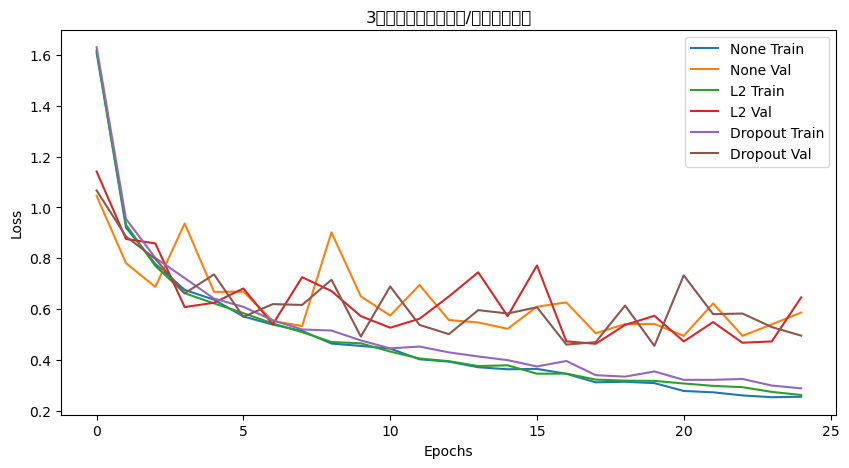

In [ ]:
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ====================== 1. 数据准备 ======================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.flatten())
])

# 用极少样本制造过拟合，方便看正则效果
train_set = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform)

# 只取少量样本，强行过拟合
train_small = torch.utils.data.Subset(train_set, range(2000))
val_small = torch.utils.data.Subset(test_set, range(500))

train_loader = torch.utils.data.DataLoader(train_small, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_small, batch_size=32, shuffle=False)

# ====================== 2. 超参数 ======================
input_dim = 784
hidden_dim = 512  # 大模型，更容易过拟合
output_dim = 10
lr = 0.1
lambda_l2 = 5e-4
dropout_rate = 0.3
epochs = 25

# ====================== 3. 手动实现 Dropout ======================
def dropout_layer(X, dropout, is_training):
    if not is_training:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return X * mask / (1.0 - dropout)

# ====================== 4. 训练函数（3种模式） ======================
def run_model(mode="none"):
    # 初始化参数
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, output_dim) * 0.01
    b2 = torch.zeros(output_dim)
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad_()

    def relu(x):
        return torch.max(x, torch.tensor(0.0))

    def softmax(x):
        x = x - x.max(dim=1, keepdim=True)[0]
        ex = torch.exp(x)
        return ex / ex.sum(dim=1, keepdim=True)

    def cross_entropy(logits, y):
        p = softmax(logits)
        return -torch.log(p[range(len(y)), y] + 1e-8).mean()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # 训练
        total_loss = 0.0
        total_num = 0
        for x, y in train_loader:
            h = x @ W1 + b1
            h = relu(h)

            # Dropout
            if mode == "dropout":
                h = dropout_layer(h, dropout_rate, is_training=True)

            logits = h @ W2 + b2
            loss = cross_entropy(logits, y)
            loss.backward()

            with torch.no_grad():
                if mode == "l2":
                    # L2 权重衰减：先乘 (1 - lr*lambda)
                    W1 *= (1 - lr * lambda_l2)
                    W2 *= (1 - lr * lambda_l2)

                # SGD 更新
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad

            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()

            total_loss += loss.item() * len(x)
            total_num += len(x)

        train_loss = total_loss / total_num

        # 验证
        val_loss = 0.0
        val_num = 0
        with torch.no_grad():
            for x, y in val_loader:
                h = x @ W1 + b1
                h = relu(h)
                if mode == "dropout":
                    h = dropout_layer(h, dropout_rate, is_training=False)
                logits = h @ W2 + b2
                loss = cross_entropy(logits, y)
                val_loss += loss.item() * len(x)
                val_num += len(x)
        val_loss /= val_num

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"[{mode}] Epoch {epoch+1:2d} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    return train_losses, val_losses

# ====================== 5. 运行3种对比 ======================
print("========== 1. 无正则化 ==========")
loss_none_train, loss_none_val = run_model("none")

print("\n========== 2. L2 权重衰减 ==========")
loss_l2_train, loss_l2_val = run_model("l2")

print("\n========== 3. Dropout ==========")
loss_drop_train, loss_drop_val = run_model("dropout")

# ====================== 6. 绘图 ======================
plt.figure(figsize=(10,5))
plt.plot(loss_none_train, label="None Train")
plt.plot(loss_none_val, label="None Val")
plt.plot(loss_l2_train, label="L2 Train")
plt.plot(loss_l2_val, label="L2 Val")
plt.plot(loss_drop_train, label="Dropout Train")
plt.plot(loss_drop_val, label="Dropout Val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("3种正则化对比：训练/验证损失曲线")
plt.legend()
plt.show()

## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸的量化分析

在深度神经网络中，反向传播时梯度的计算包含多层矩阵和激活函数导数的连乘项：
$$
\frac{\partial \mathbf{h}^{d}}{\partial \mathbf{h}^t} = \prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i}
$$
其中每一项可表示为：
$$
\frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \mathbf{W}^T \cdot \text{diag}\left( \sigma'(\mathbf{z}^i) \right)
$$
- $\mathbf{W}$ 是权重矩阵
- $\sigma'(\mathbf{z}^i)$ 是激活函数在第 $i$ 层预激活值处的导数

#### 梯度消失
当每一层的矩阵与激活函数导数乘积的**谱范数小于 1**时，即：
$$
\left\| \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \right\| < 1
$$
随着层数 $d-t$ 的增加，连乘的结果会指数级衰减趋近于 0，导致靠近输入层的参数梯度变得极小，无法有效更新。
典型场景：
- 使用 Sigmoid 或 tanh 激活函数，在饱和区导数接近 0
- 权重初始化过小，导致矩阵乘积的范数小于 1

#### 梯度爆炸
当每一层的矩阵与激活函数导数乘积的**谱范数大于 1**时，即：
$$
\left\| \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} \right\| > 1
$$
随着层数 $d-t$ 的增加，连乘的结果会指数级增长，导致梯度变得极大，参数更新时发生震荡甚至溢出。
典型场景：
- 权重初始化过大，导致矩阵乘积的范数大于 1
- 未做梯度裁剪，梯度值无限制放大

---

### 2. ReLU 缓解梯度消失的原因

ReLU 激活函数的定义为：
$$
\text{ReLU}(x) = \max(0, x)
$$
其导数为：
$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \le 0
\end{cases}
$$

它缓解梯度消失的核心原因：
1.  **正区间导数恒为 1**：当 $x>0$ 时，导数为 1，反向传播时梯度在这一路径上不会衰减，连乘时不会出现指数级缩小的情况。
2.  **避免饱和区梯度消失**：与 Sigmoid/tanh 不同，ReLU 在输入为正时不存在导数趋近于 0 的饱和区，梯度可以稳定回传到输入层。
3.  **单侧抑制与稀疏性**：部分神经元会输出 0，形成稀疏表示，同时也避免了大量梯度被“稀释”的问题。

In [3]:
import torch.nn as nn
# 20层网络
model = nn.Sequential(*[
    nn.Sequential(nn.Linear(256,256), nn.Sigmoid()) for _ in range(19)
] + [nn.Linear(256,10)])

# 初始化
for m in model.modules():
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=1)

# 前向+反向，观察梯度范数
x = torch.randn(32,256)
y = model(x)
y.sum().backward()
for i, layer in enumerate(model):
    if hasattr(layer, 'weight') and layer.weight is not None:
        print(i, layer.weight.grad.norm().item())

19 1038.9735107421875


## 5.1 理论计算题

### 协变量偏移（Covariate Shift）与标签偏移（Label Shift）的区别与联系

---

#### 1. 协变量偏移（Covariate Shift）
**定义**：
训练数据和测试数据的**输入分布不同**，即 $p(x) \neq q(x)$，但条件分布 $p(y|x) = q(y|x)$ 保持不变。
也就是说，“特征和标签的映射关系”没有变，只是“特征本身的分布”发生了变化。

**实际例子（电商推荐场景）**：
- 训练场景：夏季的用户数据，用户浏览、购买的商品以短袖、凉鞋、防晒霜为主。
- 测试场景：冬季的用户数据，用户浏览、购买的商品以羽绒服、雪地靴、暖宝宝为主。
- 偏移分析：用户的购买偏好（$p(y|x)$）并没有改变（比如“喜欢高性价比商品的用户，在冬夏都会选择该价位的产品”），但用户的浏览和购买商品分布（$p(x)$）发生了明显变化，属于典型的协变量偏移。

**核心特点**：
- 模型学习的决策边界是有效的，但测试数据分布偏离了训练分布，导致泛化性能下降。
- 缓解方法：重要性加权、领域自适应、重新采样。

---

#### 2. 标签偏移（Label Shift）
**定义**：
训练数据和测试数据的**标签分布不同**，即 $p(y) \neq q(y)$，但条件分布 $p(x|y) = q(x|y)$ 保持不变。
也就是说，“标签对应的特征分布”没有变，只是“标签本身的分布”发生了变化。

**实际例子（医疗诊断场景）**：
- 训练场景：三甲医院的病例数据，大部分是重症患者，阳性样本占比高。
- 测试场景：社区医院的体检数据，大部分是健康人群，阳性样本占比低。
- 偏移分析：阳性患者的影像特征（$p(x|y=1)$）和阴性患者的影像特征（$p(x|y=0)$）在两种场景下没有差异，但阳性样本的整体比例（$p(y)$）发生了变化，属于典型的标签偏移。

**核心特点**：
- 模型学习的“特征-标签对应关系”是有效的，但标签的先验分布发生了变化，导致预测时的类别概率出现偏差。
- 缓解方法：标签分布校正、先验调整、重要性加权。

---

#### 3. 两者的联系与区别

| 对比维度 | 协变量偏移（Covariate Shift） | 标签偏移（Label Shift） |
| :--- | :--- | :--- |
| **偏移主体** | 输入分布 $p(x)$ | 标签分布 $p(y)$ |
| **不变的分布** | 条件分布 $p(y|x)$ | 条件分布 $p(x|y)$ |
| **本质原因** | 数据采集环境/场景变化，导致特征分布改变 | 数据采集人群/样本构成变化，导致标签比例改变 |
| **典型场景** | 电商季节变化、语音识别环境噪声变化 | 医疗不同医院的病例比例变化、推荐系统冷启动用户变化 |
| **通用缓解思路** | 基于输入分布差异的重要性加权 | 基于标签分布差异的先验校正 |

**联系**：
两者都属于**分布偏移（Distribution Shift）**的范畴，都是训练集和测试集的数据分布不一致，会导致模型泛化能力下降，都可以通过重要性加权的方法进行缓解。

**区别**：
偏移的对象不同，导致问题的本质和缓解方法的侧重点不同：协变量偏移关注特征分布的变化，而标签偏移关注标签先验分布的变化。

In [4]:
import torch
# 造数据
n_train, n_test = 1000,500
x_train = torch.randn(n_train) + (-1)
y_train = 2 * x_train + 0.1*torch.randn(n_train)
x_test  = torch.randn(n_test) + 2
y_test  = 2 * x_test + 0.1*torch.randn(n_test)

# 基线线性回归
def mse(pred, y): return ((pred-y)**2).mean()
w = torch.tensor([0.], requires_grad=True)
for _ in range(200):
    loss = mse(w*x_train, y_train)
    loss.backward()
    with torch.no_grad(): w -= 0.01*w.grad
    w.grad.zero_()
print('Baseline MSE:', mse(w*x_test, y_test).item())

# 权重修正
X = torch.cat([x_train, x_test]).reshape(-1,1)
Y = torch.cat([torch.zeros(n_train), torch.ones(n_test)])
clf = nn.Linear(1,1)
opt = torch.optim.SGD(clf.parameters(), 0.1)
for _ in range(200):
    loss = nn.BCEWithLogitsLoss()(clf(X), Y.reshape(-1,1))
    loss.backward()
    opt.step()
    opt.zero_grad()

# 计算样本权重
with torch.no_grad():
    p_test = torch.sigmoid(clf(x_train.reshape(-1,1))).ravel()
p_train = 1 - p_test
w_sample = p_test / (p_train + 1e-8)

# 加权回归
w2 = torch.tensor([0.], requires_grad=True)
for _ in range(300):
    pred = w2 * x_train
    loss = (w_sample * (pred - y_train)**2).mean()
    loss.backward()
    with torch.no_grad(): w2 -= 0.01*w2.grad
    w2.grad.zero_()
print('Weighted MSE:', mse(w2*x_test, y_test).item())

Baseline MSE: 0.009769286960363388
Weighted MSE: 0.3431392014026642
